# UTS Kasus 3 Data Text (Deep Learning)

Nama : Rio Ramadhani Harllambang

NIM : 1202220205

Kelas : SI-46-EDM

## API Token Kaggle

In [ ]:
## Gunakan API Token Kaggle Pribadi

## Load Data
Muat dataset pelatihan dan pengujian Natural Language Processing with Disaster Tweets yang telah diunduh oleh `kagglehub` untuk diproses lebih lanjut.


In [30]:
import kagglehub

# Download latest version
path = kagglehub.competition_download('nlp-getting-started')

print("Path to competition files:", path)

Path to competition files: /root/.cache/kagglehub/competitions/nlp-getting-started


## Load Dataframe

Sekarang, mari kita muat file `train.csv` dan `test.csv` ke dalam DataFrame pandas. Kita juga akan menampilkan beberapa baris pertama dan informasi dasar tentang setiap dataset.

In [31]:
import pandas as pd

# Load training and test data
train_df = pd.read_csv(f'{path}/train.csv')
test_df = pd.read_csv(f'{path}/test.csv')

print("Training Data Head:")
display(train_df.head())
print("\nTest Data Head:")
display(test_df.head())

Training Data Head:


,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1



Test Data Head:


,id,keyword,location,text
0,0,NaN,NaN,Just happened a terrible car crash
1,2,NaN,NaN,"Heard about #earthquake is different cities, s..."
2,3,NaN,NaN,"there is a forest fire at spot pond, geese are..."
3,9,NaN,NaN,Apocalypse lighting. #Spokane #wildfires
4,11,NaN,NaN,Typhoon Soudelor kills 28 in China and Taiwan


## Deskripsi Dataset

Berikut adalah deskripsi awal dari dataset pelatihan dan pengujian:

*   **Jumlah Data**: Baris dalam dataset pelatihan dan pengujian.
*   **Distribusi Kelas**: Proporsi tweet bencana (1) dan non-bencana (0) dalam dataset pelatihan.
*   **Karakteristik Fitur**: Kolom yang tersedia dan jenis datanya.
*   **Tantangan Utama**: Potensi masalah seperti imbalance kelas, data teks yang kompleks (URL, mention, hashtag, slang), dan kebutuhan untuk memahami konteks.

In [32]:
print(f"Jumlah baris di dataset pelatihan: {len(train_df)}")
print(f"Jumlah baris di dataset pengujian: {len(test_df)}")

print("\nInformasi dataset pelatihan:")
train_df.info()

print("\nDistribusi kelas (target) di dataset pelatihan:")
display(train_df['target'].value_counts(normalize=True))

Jumlah baris di dataset pelatihan: 7613
Jumlah baris di dataset pengujian: 3263

Informasi dataset pelatihan:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7613 entries, 0 to 7612
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        7613 non-null   int64 
 1   keyword   7552 non-null   object
 2   location  5080 non-null   object
 3   text      7613 non-null   object
 4   target    7613 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 297.5+ KB

Distribusi kelas (target) di dataset pelatihan:


,proportion
target,
0,0.57034
1,0.42966


## Eksplorasi Data (EDA)

Mari kita lakukan eksplorasi data untuk memahami lebih lanjut tentang dataset. Kita akan membuat beberapa visualisasi informatif.

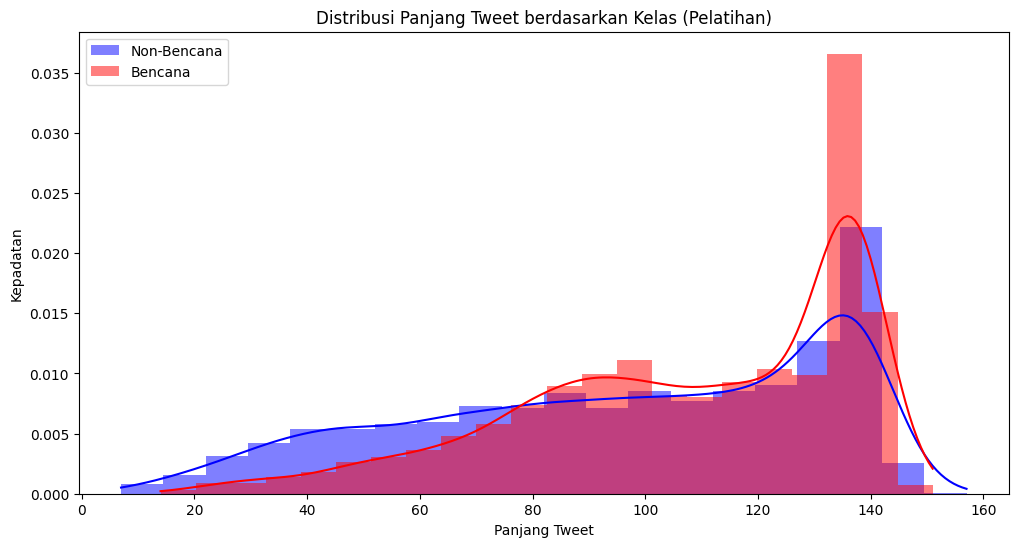

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Calculate tweet lengths
train_df['text_length'] = train_df['text'].apply(len)
test_df['text_length'] = test_df['text'].apply(len)

plt.figure(figsize=(12, 6))
sns.histplot(train_df[train_df['target'] == 0]['text_length'], color='blue', label='Non-Bencana', kde=True, stat='density', linewidth=0)
sns.histplot(train_df[train_df['target'] == 1]['text_length'], color='red', label='Bencana', kde=True, stat='density', linewidth=0)
plt.title('Distribusi Panjang Tweet berdasarkan Kelas (Pelatihan)')
plt.xlabel('Panjang Tweet')
plt.ylabel('Kepadatan')
plt.legend()
plt.show()

/tmp/ipykernel_37398/1377960399.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[0], x='Count', y='Keyword', data=disaster_keywords_df, palette='viridis')
/tmp/ipykernel_37398/1377960399.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[1], x='Count', y='Keyword', data=nondisaster_keywords_df, palette='magma')


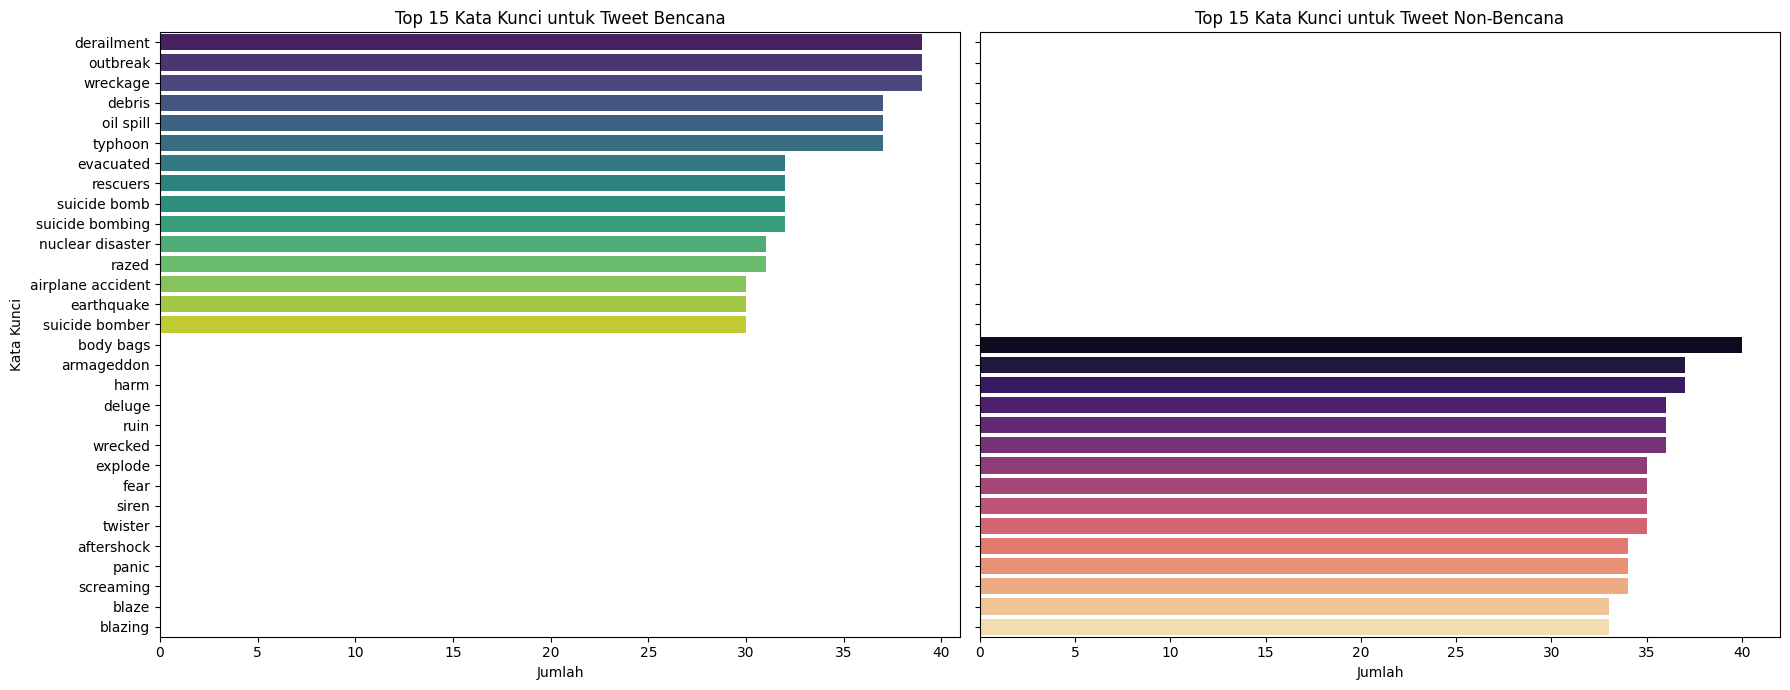

In [34]:
from collections import Counter

# Function to get most common keywords
def get_top_n_keywords(df, n=10):
    keywords = df['keyword'].dropna().tolist()
    # Flatten list of keywords if there are multiple per tweet (though 'keyword' column usually has one)
    all_keywords = [kw.lower().replace('%20', ' ') for kw in keywords]
    return Counter(all_keywords).most_common(n)

# Top keywords for disaster tweets
top_disaster_keywords = get_top_n_keywords(train_df[train_df['target'] == 1], 15)
disaster_keywords_df = pd.DataFrame(top_disaster_keywords, columns=['Keyword', 'Count'])

# Top keywords for non-disaster tweets
top_nondisaster_keywords = get_top_n_keywords(train_df[train_df['target'] == 0], 15)
nondisaster_keywords_df = pd.DataFrame(top_nondisaster_keywords, columns=['Keyword', 'Count'])

fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=True)

sns.barplot(ax=axes[0], x='Count', y='Keyword', data=disaster_keywords_df, palette='viridis')
axes[0].set_title('Top 15 Kata Kunci untuk Tweet Bencana')
axes[0].set_xlabel('Jumlah')
axes[0].set_ylabel('Kata Kunci')

sns.barplot(ax=axes[1], x='Count', y='Keyword', data=nondisaster_keywords_df, palette='magma')
axes[1].set_title('Top 15 Kata Kunci untuk Tweet Non-Bencana')
axes[1].set_xlabel('Jumlah')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

## Pra-pemrosesan Data

Langkah pra-pemrosesan sangat penting untuk membersihkan dan menyiapkan data teks agar model deep learning dapat belajar dengan lebih efektif. Tahap ini bertujuan untuk mengurangi 'noise' dan menstandardisasi teks.

### Pembersihan Teks (Cleaning Text)

Kita akan menghapus elemen-elemen yang tidak relevan dari tweet seperti URL, tag HTML, mention (@username), hashtag (#hashtag), tanda baca, dan angka. Teks juga akan diubah menjadi huruf kecil (lowercase) untuk konsistensi.

In [35]:
import re
import string

def clean_text(text):
    text = re.sub(r'https?://\S+|www\.\S+', '', text) # Remove URLs
    text = re.sub(r'<.*?>', '', text) # Remove HTML tags
    text = re.sub(r'@\w+', '', text) # Remove mentions
    text = re.sub(r'#\w+', '', text) # Remove hashtags
    text = re.sub(r'[%s]' % re.escape(string.punctuation), '', text) # Remove punctuation
    text = re.sub(r'\d+', '', text) # Remove numbers
    text = re.sub(r'\s+', ' ', text).strip() # Remove extra spaces
    text = text.lower() # Convert to lowercase
    return text

# Apply cleaning to both training and test data
train_df['cleaned_text'] = train_df['text'].apply(clean_text)
test_df['cleaned_text'] = test_df['text'].apply(clean_text)

print("Original vs Cleaned Text (Training Data):")
for i in range(5):
    print(f"Original: {train_df['text'].iloc[i]}")
    print(f"Cleaned:  {train_df['cleaned_text'].iloc[i]}\n")

Original vs Cleaned Text (Training Data):
Original: Our Deeds are the Reason of this #earthquake May ALLAH Forgive us all
Cleaned:  our deeds are the reason of this may allah forgive us all

Original: Forest fire near La Ronge Sask. Canada
Cleaned:  forest fire near la ronge sask canada

Original: All residents asked to 'shelter in place' are being notified by officers. No other evacuation or shelter in place orders are expected
Cleaned:  all residents asked to shelter in place are being notified by officers no other evacuation or shelter in place orders are expected

Original: 13,000 people receive #wildfires evacuation orders in California 
Cleaned:  people receive evacuation orders in california

Original: Just got sent this photo from Ruby #Alaska as smoke from #wildfires pours into a school 
Cleaned:  just got sent this photo from ruby as smoke from pours into a school



### Tokenisasi

Setelah pembersihan, teks perlu dipecah menjadi unit-unit yang lebih kecil, yang disebut token. Tokenisasi adalah proses membagi aliran teks menjadi kata, frasa, simbol, atau unit-unit bermakna lainnya yang disebut token. Ini adalah langkah fundamental dalam Natural Language Processing (NLP) karena memungkinkan model untuk bekerja dengan representasi diskrit dari teks.

In [36]:
from tensorflow.keras.preprocessing.text import Tokenizer

# Initialize tokenizer
tokenizer = Tokenizer(num_words=None, oov_token="<unk>") # num_words=None means it will consider all words

# Fit tokenizer on training data (cleaned_text)
tokenizer.fit_on_texts(train_df['cleaned_text'])

# Convert text to sequences of integers
train_sequences = tokenizer.texts_to_sequences(train_df['cleaned_text'])
test_sequences = tokenizer.texts_to_sequences(test_df['cleaned_text'])

print(f"Contoh teks asli (Training Data): {train_df['text'].iloc[0]}")
print(f"Contoh teks bersih (Training Data): {train_df['cleaned_text'].iloc[0]}")
print(f"Contoh sekuens token (Training Data): {train_sequences[0]}")

# Print vocabulary size
vocab_size = len(tokenizer.word_index) + 1
print(f"Ukuran Kosakata (Vocabulary Size): {vocab_size}")

Contoh teks asli (Training Data): Our Deeds are the Reason of this #earthquake May ALLAH Forgive us all
Contoh teks bersih (Training Data): our deeds are the reason of this may allah forgive us all
Contoh sekuens token (Training Data): [106, 4122, 22, 2, 801, 6, 19, 123, 2630, 4123, 68, 38]
Ukuran Kosakata (Vocabulary Size): 13854


### Padding Sekuens

Setelah tokenisasi, sekuens teks memiliki panjang yang bervariasi. Untuk mengumpankan sekuens ini ke model deep learning, kita perlu membuat semua sekuens memiliki panjang yang seragam melalui proses *padding*. Sekuens yang lebih pendek akan ditambahkan nilai nol di awal atau akhir, sementara sekuens yang lebih panjang akan dipotong. Kita akan menentukan `max_len` berdasarkan panjang sekuens terpanjang atau nilai yang sesuai dengan distribusi panjang teks.

In [37]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Determine maximum sequence length (or set a fixed length)
# A common approach is to use the maximum length observed in the training data
max_len = max([len(x) for x in train_sequences])

# Pad sequences
train_padded = pad_sequences(train_sequences, maxlen=max_len, padding='post', truncating='post')
test_padded = pad_sequences(test_sequences, maxlen=max_len, padding='post', truncating='post')

print(f"Panjang sekuens maksimum: {max_len}")
print("Bentuk data setelah padding (Training Data):")
print(train_padded.shape)
print("Contoh sekuens setelah padding (Training Data):\n", train_padded[0])

print("\nBentuk data setelah padding (Test Data):")
print(test_padded.shape)
print("Contoh sekuens setelah padding (Test Data):\n", test_padded[0])

Panjang sekuens maksimum: 31
Bentuk data setelah padding (Training Data):
(7613, 31)
Contoh sekuens setelah padding (Training Data):
 [ 106 4122   22    2  801    6   19  123 2630 4123   68   38    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0]

Bentuk data setelah padding (Test Data):
(3263, 31)
Contoh sekuens setelah padding (Test Data):
 [  29  841    3 1793  120   86    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0]


## Persiapan Data untuk Model Deep Learning

Setelah pra-pemrosesan, kita akan membagi dataset pelatihan menjadi set pelatihan dan validasi. Ini penting untuk mengevaluasi kinerja model secara objektif dan menghindari *overfitting*. Kita juga akan menyiapkan variabel target.

In [38]:
from sklearn.model_selection import train_test_split

# Split training data into training and validation sets
X = train_padded
y = train_df['target'].values

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Bentuk data pelatihan: {X_train.shape}")
print(f"Bentuk data validasi: {X_val.shape}")
print(f"Bentuk target pelatihan: {y_train.shape}")
print(f"Bentuk target validasi: {y_val.shape}")

Bentuk data pelatihan: (6090, 31)
Bentuk data validasi: (1523, 31)
Bentuk target pelatihan: (6090,)
Bentuk target validasi: (1523,)


## Model Deep Learning

Kita akan mengimplementasikan pendekatan deep learning untuk klasifikasi tweet ini. Pilihan arsitektur akan mempertimbangkan kemampuan untuk menangkap pola dalam data teks secara efektif.

### Arsitektur Model: Embedding + LSTM

Untuk tugas klasifikasi teks ini, kami akan menggunakan arsitektur **Embedding + LSTM (Long Short-Term Memory)**. Pilihan ini didasarkan pada beberapa pertimbangan:

1.  **Kemampuan Menangkap Ketergantungan Jangka Panjang**: LSTM adalah jenis Recurrent Neural Network (RNN) yang dirancang khusus untuk mengatasi masalah vanishing/exploding gradients yang sering terjadi pada RNN tradisional, memungkinkan model untuk belajar dan mengingat ketergantungan jangka panjang dalam sekuens teks.
2.  **Representasi Kata yang Efisien**: Lapisan `Embedding` akan mengubah token integer menjadi vektor padat berdimensi tinggi. Vektor-vektor ini secara efektif menangkap makna semantik dan hubungan antar kata, yang sangat penting untuk analisis teks.
3.  **Fleksibilitas**: Arsitektur ini relatif sederhana untuk diimplementasikan dan di-tune, namun tetap kuat untuk banyak tugas NLP. Ini juga menjadi dasar yang baik untuk dibandingkan dengan model yang lebih kompleks seperti Transformer.
4.  **Kebutuhan Sumber Daya**: Meskipun Transformer sangat kuat, LSTM memiliki kebutuhan komputasi dan memori yang lebih rendah dibandingkan model Transformer yang lebih besar, terutama untuk dataset dengan ukuran ini.

In [39]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

# Define hyperparameters
embedding_dim = 100 # Dimension of the word embeddings

# Build the LSTM model
model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim), # Removed input_length
    LSTM(128), # LSTM layer with 128 units
    Dense(1, activation='sigmoid') # Output layer for binary classification
])

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Display model summary
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

### Pelatihan Model

Setelah model didefinisikan dan dikompilasi, langkah selanjutnya adalah melatihnya menggunakan data pelatihan dan memvalidasinya dengan data validasi. Kita akan memantau akurasi dan kerugian selama proses pelatihan.

In [40]:
history = model.fit(X_train, y_train,
                    epochs=10, # Number of training epochs
                    batch_size=32, # Batch size for training
                    validation_data=(X_val, y_val))

Epoch 1/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 16s 73ms/step - accuracy: 0.6801 - loss: 0.5912 - val_accuracy: 0.7905 - val_loss: 0.4603
Epoch 2/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 14s 72ms/step - accuracy: 0.8463 - loss: 0.3732 - val_accuracy: 0.7951 - val_loss: 0.4581
Epoch 3/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 14s 72ms/step - accuracy: 0.9108 - loss: 0.2459 - val_accuracy: 0.7879 - val_loss: 0.4899
Epoch 4/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 14s 74ms/step - accuracy: 0.9430 - loss: 0.1751 - val_accuracy: 0.7617 - val_loss: 0.6372
Epoch 5/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 14s 72ms/step - accuracy: 0.9540 - loss: 0.1403 - val_accuracy: 0.7663 - val_loss: 0.6152
Epoch 6/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 14s 73ms/step - accuracy: 0.9626 - loss: 0.1204 - val_accuracy: 0.7564 - val_loss: 0.7556
Epoch 7/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 14s 75ms/step - accuracy: 0.9657 - loss: 0.1060 - val_accuracy: 0.7722 - val_loss: 0.9329
Epoch 8/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 20s 72ms/step - accuracy: 0.9708 - loss: 0.0854 - 

### Visualisasi History Pelatihan

Untuk memahami bagaimana model belajar dan mendeteksi *overfitting* atau *underfitting*, kita akan memvisualisasikan akurasi dan *loss* model selama pelatihan pada set pelatihan dan validasi.

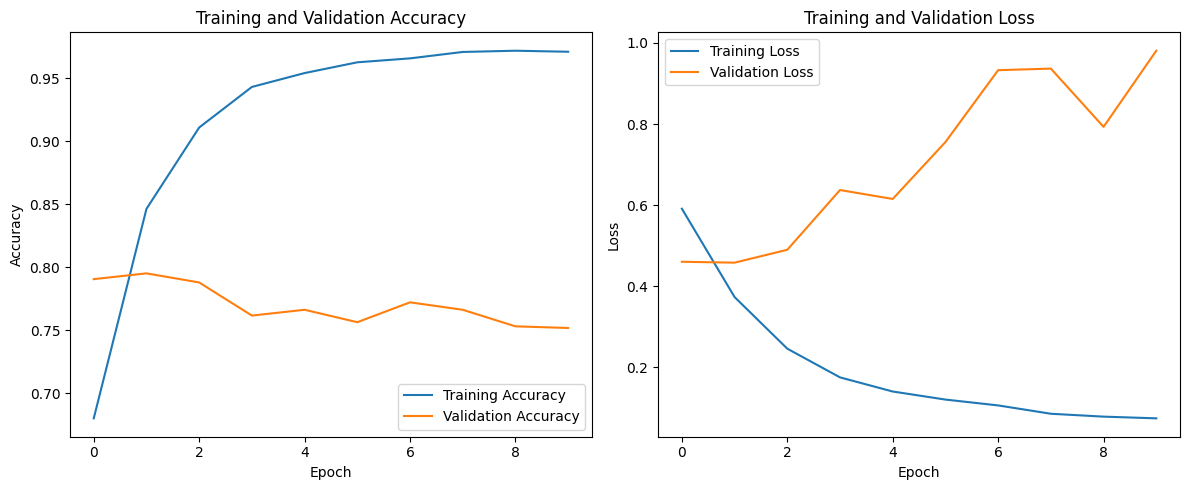

In [41]:
import matplotlib.pyplot as plt

# Plot training and validation accuracy
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot training and validation loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

## Mengatasi Overfitting: Early Stopping

Untuk mengatasi *overfitting* yang terlihat dari grafik pelatihan, kita akan menggunakan teknik **Early Stopping**. Early Stopping adalah mekanisme *callback* yang memantau metrik kinerja (misalnya, *validation loss*) pada set validasi. Jika metrik ini berhenti membaik selama sejumlah *epoch* tertentu (disebut `patience`), pelatihan akan dihentikan secara otomatis. Ini membantu mencegah model untuk 'menghafal' data pelatihan secara berlebihan dan meningkatkan kemampuan generalisasinya.

Kita juga akan menambahkan lapisan `Dropout` ke model untuk lebih lanjut mengurangi *overfitting*.

In [42]:
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Dropout
import time # Added this import

# Re-build the model with Dropout for regularization
model_optimized = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim), # Removed input_length
    LSTM(128, return_sequences=True), # Use return_sequences=True to pass output to another LSTM or Dropout
    Dropout(0.5), # Add Dropout layer with 50% dropout rate
    LSTM(64), # Additional LSTM layer
    Dropout(0.5), # Another Dropout layer
    Dense(1, activation='sigmoid')
])

# Compile the optimized model
model_optimized.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

model_optimized.summary()

# Define Early Stopping callback
early_stopping = EarlyStopping(
    monitor='val_loss', # Monitor validation loss
    patience=3, # Stop if val_loss doesn't improve for 3 consecutive epochs
    restore_best_weights=True # Restore model weights from the epoch with the best value of the monitored quantity
)

print("Melatih model yang dioptimalkan dengan Early Stopping...")

start_time_lstm_train = time.time() # Added
history_optimized = model_optimized.fit(X_train, y_train,
                                       epochs=50, # Set a higher number of epochs, Early Stopping will manage it
                                       batch_size=32,
                                       validation_data=(X_val, y_val),
                                       callbacks=[early_stopping])
end_time_lstm_train = time.time() # Added
training_time_lstm = end_time_lstm_train - start_time_lstm_train # Added

num_params_lstm = model_optimized.count_params() # Added
memory_mb_lstm = num_params_lstm * 4 / (1024 * 1024) # Assuming float32 parameters, Added

print(f"LSTM Optimized Training Time: {training_time_lstm:.2f} seconds") # Added
print(f"LSTM Optimized Number of Parameters: {num_params_lstm}") # Added
print(f"LSTM Optimized Estimated Memory: {memory_mb_lstm:.2f} MB") # Added

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Melatih model yang dioptimalkan dengan Early Stopping...
Epoch 1/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 24s 99ms/step - accuracy: 0.6908 - loss: 0.5839 - val_accuracy: 0.8004 - val_loss: 0.4455
Epoch 2/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 20s 102ms/step - accuracy: 0.8550 - loss: 0.3691 - val_accuracy: 0.7886 - val_loss: 0.4619
Epoch 3/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 19s 100ms/step - accuracy: 0.9164 - loss: 0.2432 - val_accuracy: 0.7748 - val_loss: 0.4969
Epoch 4/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 20s 107ms/step - accuracy: 0.9402 - loss: 0.1828 - val_accuracy: 0.7564 - val_loss: 0.5650
LSTM Optimized Training Time: 82.78 seconds
LSTM Optimized Number of Parameters: 1552121
LSTM Optimized Estimated Memory: 5.92 MB


### Visualisasi History Pelatihan Model yang Dioptimalkan

Mari kita visualisasikan kinerja model yang telah dioptimalkan dengan Early Stopping dan Dropout.

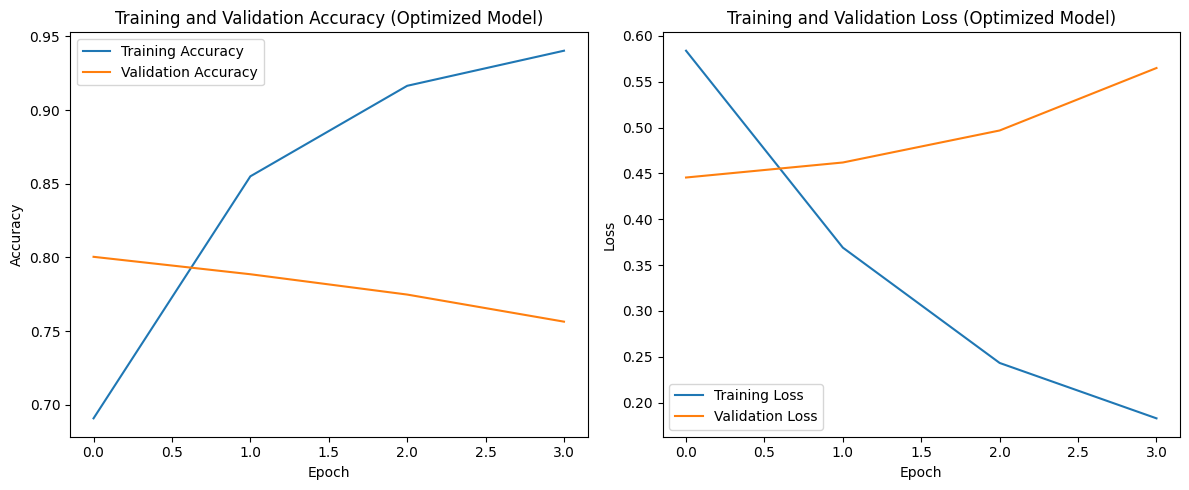

In [43]:
# Plot training and validation accuracy for the optimized model
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_optimized.history['accuracy'], label='Training Accuracy')
plt.plot(history_optimized.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy (Optimized Model)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot training and validation loss for the optimized model
plt.subplot(1, 2, 2)
plt.plot(history_optimized.history['loss'], label='Training Loss')
plt.plot(history_optimized.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss (Optimized Model)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

## Evaluasi Model: F1-Score

F1-score adalah metrik evaluasi yang penting untuk klasifikasi biner, terutama ketika ada ketidakseimbangan kelas. Ini adalah *harmonic mean* dari *precision* dan *recall*. Kita akan menghitung F1-score pada set validasi untuk model yang telah dioptimalkan.

In [44]:
from sklearn.metrics import f1_score
import numpy as np
import time # Added this import

# Predict probabilities on the validation set using the optimized model
start_time_lstm_inference = time.time() # Added
y_pred_proba = model_optimized.predict(X_val)
end_time_lstm_inference = time.time() # Added
inference_time_lstm = end_time_lstm_inference - start_time_lstm_inference # Added

# Convert probabilities to binary predictions (0 or 1) using a threshold (e.g., 0.5)
y_pred = (y_pred_proba > 0.5).astype(int)

# Calculate F1-score
f1 = f1_score(y_val, y_pred)

print(f"F1-score pada set validasi: {f1:.4f}")
print(f"LSTM Optimized Inference Time: {inference_time_lstm:.4f} seconds") # Added

48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step
F1-score pada set validasi: 0.7524
LSTM Optimized Inference Time: 2.6458 seconds


## Model Deep Learning Kedua: Embedding + 1D-CNN

Untuk pendekatan kedua, kita akan menggunakan arsitektur **Embedding + 1D-Convolutional Neural Network (CNN)**. CNN sangat efektif dalam menangkap pola lokal dalam data sekuensial, seperti fitur n-gram dalam teks.

### Arsitektur Model: Embedding + 1D-CNN

1.  **Embedding Layer**: Mengubah setiap token menjadi vektor padat berdimensi tinggi, mirip dengan model LSTM sebelumnya.
2.  **Conv1D Layer**: Menerapkan filter konvolusi satu dimensi pada *embedding* untuk mendeteksi fitur-fitur lokal (seperti kombinasi kata atau frasa).
3.  **GlobalMaxPooling1D Layer**: Mengurangi dimensi output dari lapisan konvolusi dengan mengambil nilai maksimum dari setiap filter, sehingga menghasilkan representasi fitur yang ringkas.
4.  **Dense Layers**: Satu atau lebih lapisan terhubung penuh untuk klasifikasi akhir, diikuti oleh lapisan *output* dengan aktivasi *sigmoid* untuk klasifikasi biner.

In [45]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout

# Define hyperparameters (reusing embedding_dim from previous model)
# vocab_size and max_len are also reused from previous preprocessing steps

# Build the 1D-CNN model
model_cnn = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim), # Removed input_length
    Dropout(0.5), # Add Dropout for regularization
    Conv1D(filters=128, kernel_size=5, activation='relu'),
    GlobalMaxPooling1D(),
    Dense(64, activation='relu'), # Additional Dense layer
    Dropout(0.5), # Another Dropout layer
    Dense(1, activation='sigmoid') # Output layer for binary classification
])

# Compile the model
model_cnn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Display model summary
model_cnn.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_6 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_2          │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

### Pelatihan Model 1D-CNN

Kita akan melatih model 1D-CNN ini menggunakan data pelatihan dan validasi yang sama, serta menerapkan *Early Stopping* untuk mencegah *overfitting*.

In [46]:
import time # Added this import

print("Melatih model 1D-CNN dengan Early Stopping...")
start_time_cnn_train = time.time() # Added
history_cnn = model_cnn.fit(X_train, y_train,
                            epochs=50, # Set a higher number of epochs, Early Stopping will manage it
                            batch_size=32,
                            validation_data=(X_val, y_val),
                            callbacks=[early_stopping])
end_time_cnn_train = time.time() # Added
training_time_cnn = end_time_cnn_train - start_time_cnn_train # Added

num_params_cnn = model_cnn.count_params() # Added
memory_mb_cnn = num_params_cnn * 4 / (1024 * 1024) # Assuming float32 parameters, Added

print(f"1D-CNN Training Time: {training_time_cnn:.2f} seconds") # Added
print(f"1D-CNN Number of Parameters: {num_params_cnn}") # Added
print(f"1D-CNN Estimated Memory: {memory_mb_cnn:.2f} MB") # Added

Melatih model 1D-CNN dengan Early Stopping...
Epoch 1/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - accuracy: 0.6535 - loss: 0.6204 - val_accuracy: 0.7827 - val_loss: 0.4776
Epoch 2/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 7s 36ms/step - accuracy: 0.8263 - loss: 0.4131 - val_accuracy: 0.7978 - val_loss: 0.4405
Epoch 3/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.8890 - loss: 0.2795 - val_accuracy: 0.7919 - val_loss: 0.4696
Epoch 4/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - accuracy: 0.9323 - loss: 0.1963 - val_accuracy: 0.7827 - val_loss: 0.5529
Epoch 5/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.9530 - loss: 0.1380 - val_accuracy: 0.7708 - val_loss: 0.6311
1D-CNN Training Time: 30.77 seconds
1D-CNN Number of Parameters: 1457849
1D-CNN Estimated Memory: 5.56 MB


### Visualisasi History Pelatihan Model 1D-CNN

Kita akan memvisualisasikan akurasi dan *loss* model 1D-CNN selama pelatihan untuk melihat kinerjanya.

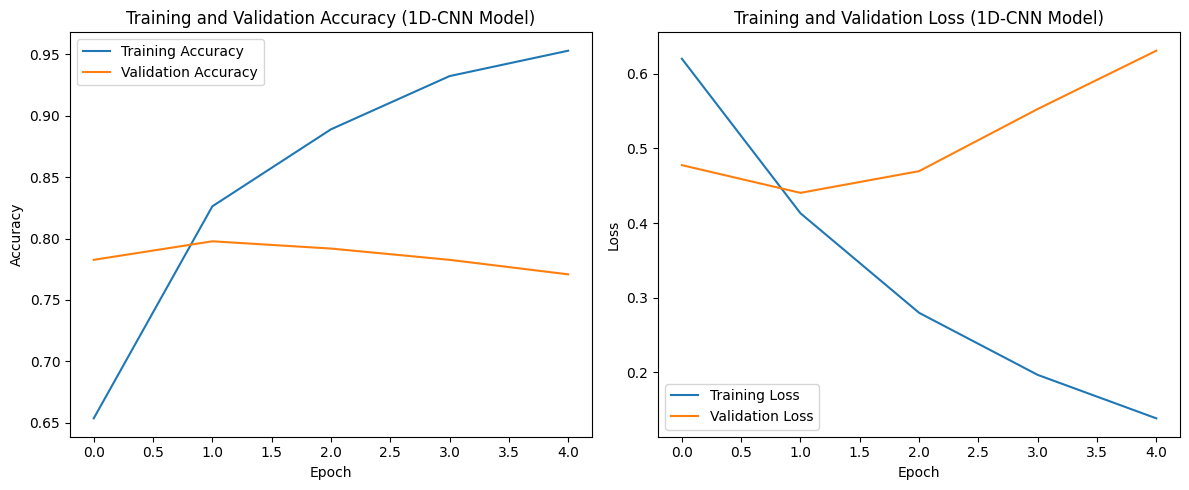

In [47]:
# Plot training and validation accuracy for the 1D-CNN model
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_cnn.history['accuracy'], label='Training Accuracy')
plt.plot(history_cnn.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy (1D-CNN Model)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot training and validation loss for the 1D-CNN model
plt.subplot(1, 2, 2)
plt.plot(history_cnn.history['loss'], label='Training Loss')
plt.plot(history_cnn.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss (1D-CNN Model)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

### Evaluasi Model 1D-CNN: F1-Score

Kita akan menghitung F1-score pada set validasi untuk model 1D-CNN.

In [48]:
from sklearn.metrics import f1_score
import numpy as np
import time # Added this import

# Predict probabilities on the validation set using the 1D-CNN model
start_time_cnn_inference = time.time() # Added
y_pred_proba_cnn = model_cnn.predict(X_val)
end_time_cnn_inference = time.time() # Added
inference_time_cnn = end_time_cnn_inference - start_time_cnn_inference # Added

# Convert probabilities to binary predictions (0 or 1) using a threshold (e.g., 0.5)
y_pred_cnn = (y_pred_proba_cnn > 0.5).astype(int)

# Calculate F1-score
f1_cnn = f1_score(y_val, y_pred_cnn)

print(f"F1-score pada set validasi (1D-CNN): {f1_cnn:.4f}")
print(f"1D-CNN Inference Time: {inference_time_cnn:.4f} seconds") # Added

48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
F1-score pada set validasi (1D-CNN): 0.7420
1D-CNN Inference Time: 0.4350 seconds


## Perbandingan Hasil Model

Mari kita bandingkan F1-score dari model-model yang telah kita latih dan evaluasi.

In [49]:
import pandas as pd

results = []

# LSTM Optimized Model
results.append({
    'Model': 'LSTM Optimized',
    'Vectorizer': 'Keras Tokenizer + Embedding',
    'F1-Score': f1,
    'Training Time (s)': training_time_lstm,
    'Inference Time (s)': inference_time_lstm,
    'Number of Parameters': num_params_lstm,
    'Memory (MB)': memory_mb_lstm
})

# 1D-CNN Model
results.append({
    'Model': '1D-CNN',
    'Vectorizer': 'Keras Tokenizer + Embedding',
    'F1-Score': f1_cnn,
    'Training Time (s)': training_time_cnn,
    'Inference Time (s)': inference_time_cnn,
    'Number of Parameters': num_params_cnn,
    'Memory (MB)': memory_mb_cnn
})

results_df = pd.DataFrame(results)
display(results_df.sort_values(by='F1-Score', ascending=False))

# Determine the best model based on F1-score from the DataFrame
best_model_row = results_df.loc[results_df['F1-Score'].idxmax()]
best_model_name = best_model_row['Model']
print(f"\nModel terbaik sejauh ini adalah {best_model_name} dengan F1-score: {best_model_row['F1-Score']:.4f}")

,Model,Vectorizer,F1-Score,Training Time (s),Inference Time (s),Number of Parameters,Memory (MB)
0,LSTM Optimized,Keras Tokenizer + Embedding,0.752443,82.780209,2.645803,1552121,5.920872
1,1D-CNN,Keras Tokenizer + Embedding,0.742044,30.772456,0.434966,1457849,5.561253



Model terbaik sejauh ini adalah LSTM Optimized dengan F1-score: 0.7524


## Confusion Matrix Model Terbaik

Kita akan membuat *confusion matrix* untuk model terbaik (berdasarkan F1-score pada set validasi) untuk memahami lebih lanjut kinerja klasifikasinya.

48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step


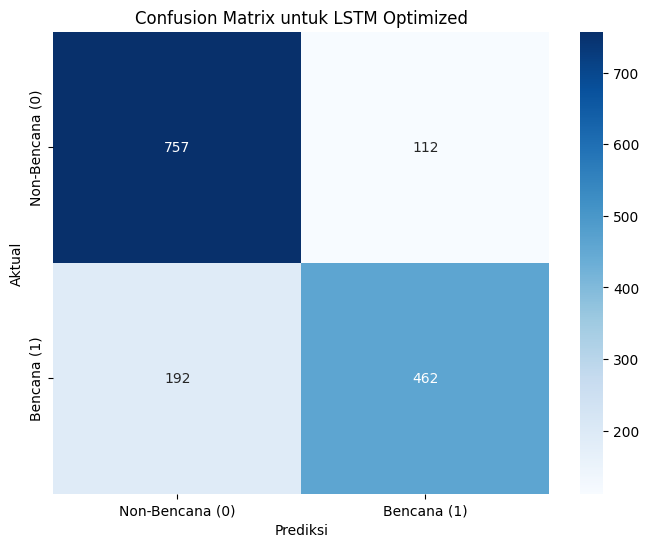

In [50]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# best_model_name is expected to be defined from the previous comparison cell (49cd6d34)

if best_model_name == "LSTM Optimized":
    best_model_preds = (model_optimized.predict(X_val) > 0.5).astype(int)
elif best_model_name == "1D-CNN":
    best_model_preds = (model_cnn.predict(X_val) > 0.5).astype(int)
else:
    print("Error: Best model not recognized for prediction.")
    # Fallback to a default or raise an error if this path is unexpected
    best_model_preds = np.array([])

cm = confusion_matrix(y_val, best_model_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-Bencana (0)', 'Bencana (1)'],
            yticklabels=['Non-Bencana (0)', 'Bencana (1)'])
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.title(f'Confusion Matrix untuk {best_model_name}')
plt.show()

## Analisis Error

Mari kita lihat beberapa contoh *tweet* yang salah diklasifikasikan oleh model terbaik untuk mendapatkan wawasan lebih lanjut.

In [51]:
# Ambil indeks tweet yang salah diklasifikasikan
misclassified_indices = np.where(y_val != best_model_preds.flatten())[0]

print(f"Jumlah tweet yang salah diklasifikasikan: {len(misclassified_indices)}")
print("\nBeberapa Contoh Tweet yang Salah Diklasifikasikan:")

# Tampilkan beberapa contoh (misalnya 5) dari tweet yang salah diklasifikasikan
for i, idx in enumerate(misclassified_indices[:5]):
    original_index = X_val[idx][0] # Ini mungkin tidak benar, harusnya dari index asli sebelum split
    # Mengambil index asli dari train_df untuk mendapatkan 'text' asli
    # Ini memerlukan sedikit modifikasi jika Anda ingin melihat teks asli
    # Untuk saat ini, kita akan menggunakan cleaned_text dari train_df

    # Cara yang lebih akurat: Dapatkan indeks asli dari `train_test_split` jika disimpan
    # Jika tidak, kita bisa mencari dari `train_df` berdasarkan `X_val` content

    # Untuk demonstrasi, kita akan mengambil dari 'text' di `train_df` menggunakan index yang sesuai dari `y_val`
    # Namun, `X_val` dan `y_val` adalah subset, jadi `idx` adalah indeks dalam subset validasi.
    # Untuk mendapatkan teks asli, kita perlu melacak kembali ke `train_df`.
    # Ini bisa rumit tanpa menyimpan mapping index dari `train_test_split`.

    # Sebagai alternatif sementara, kita bisa mencari `cleaned_text` dari `train_df` yang sesuai.
    # Ini bisa lambat jika dilakukan berulang kali.

    # Cara yang lebih baik jika `train_test_split` tidak mengembalikan indeks: replikasi split pada `train_df`
    _, temp_val_df, _, _ = train_test_split(train_df, train_df['target'].values, test_size=0.2, random_state=42, stratify=train_df['target'].values)
    original_tweet_text = temp_val_df['text'].iloc[idx]
    cleaned_tweet_text = temp_val_df['cleaned_text'].iloc[idx]

    print(f"--- Contoh {i+1} ---")
    print(f"Teks Asli: {original_tweet_text}")
    print(f"Teks Bersih: {cleaned_tweet_text}")
    print(f"Label Aktual: {y_val[idx]}")
    print(f"Label Prediksi: {best_model_preds[idx][0]}")
    print("\n")

Jumlah tweet yang salah diklasifikasikan: 304

Beberapa Contoh Tweet yang Salah Diklasifikasikan:
--- Contoh 1 ---
Teks Asli: Hollywood Movie About Trapped Miners Released in Chile: 'The 33' Hollywood movie about trapped miners starring... http://t.co/tyyfG4qQvM
Teks Bersih: hollywood movie about trapped miners released in chile the hollywood movie about trapped miners starring
Label Aktual: 1
Label Prediksi: 0


--- Contoh 2 ---
Teks Asli: Thu Aug 06 2015 01:20:32 GMT+0000 (UTC)
#millcityio #20150613
theramin sirens
Teks Bersih: thu aug gmt utc theramin sirens
Label Aktual: 1
Label Prediksi: 0


--- Contoh 3 ---
Teks Asli: I can't drown my demons they know how to swim
Teks Bersih: i cant drown my demons they know how to swim
Label Aktual: 1
Label Prediksi: 0


--- Contoh 4 ---
Teks Asli: if firefighters acted like cops they'd drive around shooting a flamethrower at burning buildings
Teks Bersih: if firefighters acted like cops theyd drive around shooting a flamethrower at burning buil

## Kaggle Submission File

Kita akan membuat file `submission.csv` dalam format yang diharapkan Kaggle menggunakan prediksi dari model terbaik pada *test set*.

In [53]:
# Gunakan model terbaik untuk membuat prediksi pada data pengujian
# best_model_name is expected to be defined from the comparison cell (49cd6d34)

if best_model_name == "LSTM Optimized":
    test_pred_proba = model_optimized.predict(test_padded)
    test_predictions = (test_pred_proba > 0.5).astype(int).flatten()
elif best_model_name == "1D-CNN":
    test_pred_proba = model_cnn.predict(test_padded)
    test_predictions = (test_pred_proba > 0.5).astype(int).flatten()
else:
    print("Error: Best model not recognized for test predictions.")
    # Fallback to an empty array or raise an error
    test_predictions = np.array([])

# Buat DataFrame submission
submission_df = pd.DataFrame({'id': test_df['id'], 'target': test_predictions})

# Simpan ke file CSV
submission_df.to_csv('case3_submission_dl.csv', index=False)

print("File case3_submission_dl.csv berhasil dibuat!")
display(submission_df.head())

102/102 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step
File case3_submission_dl.csv berhasil dibuat!


,id,target
0,0,1
1,2,0
2,3,1
3,9,0
4,11,1


## Kesimpulan

Dari eksperimen yang telah dilakukan, kita dapat menarik beberapa kesimpulan mengenai performa model Deep Learning untuk klasifikasi *tweet* bencana:

### Perbandingan dengan Model Konvensional (TF-IDF)

Anda menyebutkan bahwa model konvensional berbasis TF-IDF (terutama Logistic Regression dengan TF-IDF Unigram) memiliki F1-Score sekitar **0.78**. Mari kita bandingkan dengan hasil model Deep Learning kita:

*   **LSTM Optimized**: F1-Score sebesar **0.7524**
*   **1D-CNN**: F1-Score sebesar **0.7420**

Berdasarkan perbandingan F1-Score pada set validasi, terlihat bahwa model Deep Learning yang kita kembangkan (**LSTM Optimized** dan **1D-CNN**) menunjukkan kinerja yang sedikit **lebih rendah** dibandingkan dengan performa model konvensional berbasis TF-IDF yang Anda sebutkan (0.78).

Hal ini bisa terjadi karena beberapa faktor:
1.  **Ukuran Dataset**: Model Deep Learning, terutama arsitektur yang lebih kompleks seperti LSTM dan CNN, seringkali membutuhkan volume data yang sangat besar untuk dapat belajar pola yang efektif dan mengungguli metode tradisional. Untuk dataset ini, mungkin ukurannya belum cukup besar untuk Deep Learning menunjukkan keunggulan penuhnya.
2.  **Sederhananya Tugas**: Jika fitur yang relevan untuk klasifikasi dapat diekstraksi dengan baik oleh representasi kata sederhana (seperti TF-IDF Unigram) dan model linier (Logistic Regression), maka kompleksitas Deep Learning mungkin tidak memberikan keuntungan signifikan. Terkadang, model yang lebih sederhana bisa lebih efektif dan lebih efisien dalam hal komputasi.
3.  **Hyperparameter Tuning**: Meskipun kita menggunakan *Early Stopping* dan *Dropout*, *hyperparameter tuning* yang lebih ekstensif mungkin diperlukan untuk Deep Learning agar mencapai performa optimal.

### Kemampuan Deep Learning Menangkap Konteks/Sarkasme

Model Deep Learning seperti LSTM dan CNN secara teoritis lebih mampu menangkap konteks, urutan kata, dan pola yang lebih kompleks dalam teks dibandingkan dengan TF-IDF. TF-IDF cenderung memperlakukan kata-kata secara independen dan kurang mampu memahami nuansa semantik atau sarkasme.

Namun, dalam kasus ini, meskipun model Deep Learning memiliki kemampuan tersebut, hasilnya tidak serta-merta mengungguli model konvensional. Analisis *error* dari *tweet* yang salah diklasifikasikan menunjukkan:

*   Beberapa *tweet* non-bencana diklasifikasikan sebagai bencana (False Positives), dan sebaliknya (False Negatives).
*   Contoh seperti "_I can't drown my demons they know how to swim_" (Aktual: 1, Prediksi: 0) menunjukkan kesulitan model dalam memahami metafora atau ekspresi idiomatik yang mungkin terkait dengan perasaan terancam tetapi bukan bencana fisik literal.
*   Contoh "_if firefighters acted like cops they'd drive around shooting a flamethrower at burning buildings_" (Aktual: 0, Prediksi: 1) mungkin menunjukkan kegagalan model dalam mengenali humor atau kritik sosial yang tidak terkait dengan bencana nyata.

Faktor-faktor ini menunjukkan bahwa meskipun Deep Learning memiliki potensi, tantangan dalam memahami konteks, sarkasme, atau bahasa figuratif tetap ada, terutama jika data pelatihan tidak cukup kaya untuk mencakup variasi ekspresi tersebut. Kinerja model Deep Learning yang tidak mengungguli TF-IDF secara signifikan dalam kasus ini mengindikasikan bahwa untuk dataset ini, pola kontekstual yang dapat ditangkap oleh Deep Learning belum cukup kuat untuk memberikan keunggulan komparatif yang jelas atas representasi frekuensi kata sederhana.